Plot 1 saved.


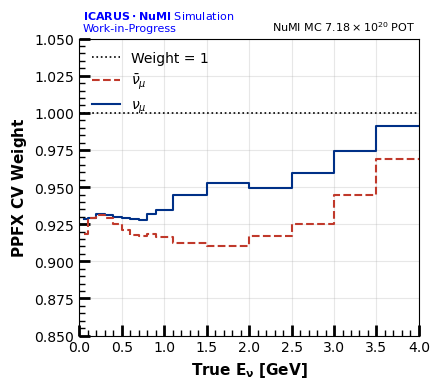

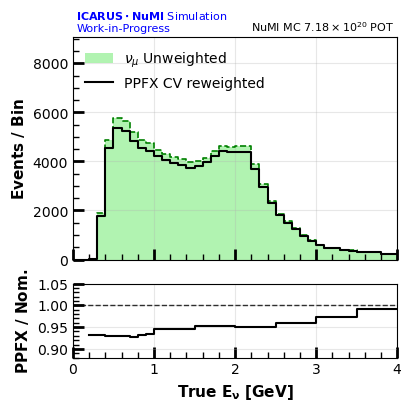

Saved: ppfx_enu_numu


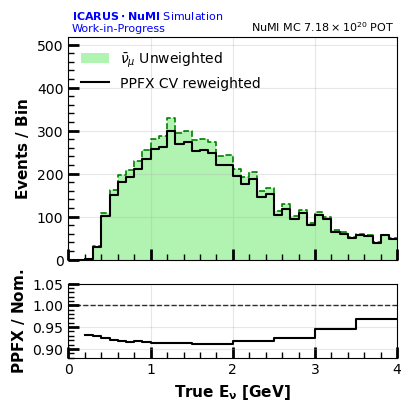

Saved: ppfx_enu_numubar

PPFX stats (νμ)   — mean: 0.9470
PPFX stats (ν̄μ)  — mean: 0.9322


In [2]:
import os
import uproot
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

FILE = (
    "/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/"
    "My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/"
    "ICARUS_CC0pi_Selection/data/icarus_numi_numu_mc_onbeam_offbeam_syst_ppfx.root"
)
FLUX_FILE = (
    "/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/"
    "My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/"
    "ICARUS_CC0pi_Selection/systematics/2025-04-08_out_450.37_7991.98_79512.66.root"
)

os.makedirs("../pdf",  exist_ok=True)
os.makedirs("../jpeg", exist_ok=True)

# --------------------------------------------------------------------------
# Style helpers
# --------------------------------------------------------------------------
def apply_tick_style(ax):
    ax.tick_params(axis='both', which='major', labelsize=10, size=8, width=2, direction='in')
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', size=4, width=1, direction='in')
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontfamily('sans-serif')
    ax.yaxis.get_offset_text().set_fontfamily('sans-serif')
    ax.xaxis.get_offset_text().set_fontfamily('sans-serif')

def add_icarus_label(ax, subtitle="Work-in-Progress"):
    yrange = ax.get_ylim()
    xrange = ax.get_xlim()
    usey = yrange[1] + 0.02 * (yrange[1] - yrange[0])
    usex = xrange[0] + 0.01 * (xrange[1] - xrange[0])
    ax.text(usex, usey,
            r'$\bf{ICARUS \cdot NuMI}$ Simulation' + '\n' + subtitle,
            fontsize=8, color="blue",
            verticalalignment="bottom", fontfamily="sans-serif")

def add_pot_label(ax, pot_str):
    yrange = ax.get_ylim()
    xrange = ax.get_xlim()
    usey   = yrange[1] + 0.02 * (yrange[1] - yrange[0])
    usex   = xrange[1] - 0.01 * (xrange[1] - xrange[0])
    ax.text(usex, usey, pot_str,
            fontsize=8, color="black",
            verticalalignment="bottom", horizontalalignment="right",
            fontfamily="sans-serif")

ICARUS_BLUE = "#003087"
ICARUS_RED  = "#C0392B"

def masked_centers(edges, vals):
    centers = 0.5 * (edges[:-1] + edges[1:])
    mask    = vals > 0
    return centers[mask], vals[mask]

# --------------------------------------------------------------------------
# Load PPFX weight histograms
# --------------------------------------------------------------------------
with uproot.open(FLUX_FILE) as ff:
    h_numu    = ff["ppfx_flux_weights/hweights_fhc_numu;1"]
    h_numubar = ff["ppfx_flux_weights/hweights_fhc_numubar;1"]

c_numu,    v_numu    = masked_centers(h_numu.axes[0].edges(),    h_numu.values())
c_numubar, v_numubar = masked_centers(h_numubar.axes[0].edges(), h_numubar.values())

# --------------------------------------------------------------------------
# Load event-level data (need true_pdg to split numu / numubar)
# --------------------------------------------------------------------------
with uproot.open(FILE) as f:
    df = f["events/full/signal"].arrays(
        ["ppfx_cv_weight", "true_neutrino_energy", "true_pdg"], library="pd"
    )

df = df[np.isfinite(df["ppfx_cv_weight"]) & np.isfinite(df["true_neutrino_energy"])]

df_numu    = df[df["true_pdg"] ==  14]
df_numubar = df[df["true_pdg"] == -14]

# ==========================================================================
# Plot 1 — PPFX CV weight vs true neutrino energy (numu and numubar)
# ==========================================================================
fig1, ax1 = plt.subplots(figsize=(4.5, 4), tight_layout=True)

ax1.step(c_numu,    v_numu,    where="mid", color=ICARUS_BLUE, linewidth=1.5,
         label=r"$\nu_\mu$")
ax1.step(c_numubar, v_numubar, where="mid", color=ICARUS_RED,  linewidth=1.5,
         linestyle="--", label=r"$\bar{\nu}_\mu$")
ax1.axhline(1.0, color="black", linestyle=":", linewidth=1.2, label="Weight = 1")

ax1.set_xlabel(r"$\mathbf{True\ E_\nu\ [GeV]}$", fontsize=11, fontfamily="sans-serif")
ax1.set_ylabel(r"$\mathbf{PPFX\ CV\ Weight}$",   fontsize=11, fontfamily="sans-serif")
ax1.set_xlim(0.0, 4.0)
ax1.set_ylim(0.85, 1.05)
ax1.grid(True, alpha=0.3)
apply_tick_style(ax1)

handles, labels_ = ax1.get_legend_handles_labels()
ax1.legend(handles[::-1], labels_[::-1], fontsize=10, loc='upper left',
           framealpha=0.0, edgecolor='none', title_fontsize=10)
add_icarus_label(ax1)
add_pot_label(ax1, r"NuMI MC $7.18\times10^{20}$ POT")

fig1.savefig("../pdf/ppfx_weight_vs_enu.pdf",   bbox_inches="tight")
fig1.savefig("../jpeg/ppfx_weight_vs_enu.jpeg",  bbox_inches="tight", dpi=200)
print("Plot 1 saved.")

# --------------------------------------------------------------------------
# Helper: make Enu comparison plot (unweighted vs PPFX) for one species
# --------------------------------------------------------------------------
def make_enu_plot(df_species, label, filename):
    enu     = df_species["true_neutrino_energy"].values
    weights = df_species["ppfx_cv_weight"].values

    bins_e = np.linspace(0.0, 4.0, 41)

    counts_nom,  edges = np.histogram(enu, bins=bins_e)
    counts_ppfx, _    = np.histogram(enu, bins=bins_e, weights=weights)
    bin_centers        = 0.5 * (edges[:-1] + edges[1:])
    bin_width          = np.diff(edges)

    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = np.where(counts_nom > 0, counts_ppfx / counts_nom, np.nan)

    fig, (ax_top, ax_bot) = plt.subplots(
        2, 1, figsize=(4, 4), sharex=True,
        gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05},
        constrained_layout=True
    )

    ax_top.bar(bin_centers, counts_nom, width=bin_width,
               color="lightgreen", alpha=0.7, label=f"{label} Unweighted")
    # Dashed green border on unweighted histogram
    ax_top.step(np.append(edges[:-1], edges[-1]),
                np.append(counts_nom, counts_nom[-1]),
                where="post", color="green", linewidth=1.2, linestyle="--")
    ax_top.step(np.append(edges[:-1], edges[-1]),
                np.append(counts_ppfx, counts_ppfx[-1]),
                where="post", color="black", linewidth=1.5,
                label="PPFX CV reweighted")
    ax_top.set_ylabel(r"$\mathbf{Events\ /\ Bin}$", fontsize=11, fontfamily="sans-serif", fontweight='bold')
    ax_top.set_xlim(edges[0], edges[-1])
    ax_top.grid(True, alpha=0.3)
    apply_tick_style(ax_top)
    plt.setp(ax_top.get_xticklabels(), visible=False)

    ymax = ax_top.get_ylim()[1]
    ax_top.set_ylim(0, ymax * 1.5)

    handles, labels_ = ax_top.get_legend_handles_labels()
    ax_top.legend(handles[::-1], labels_[::-1], fontsize=10, loc='upper left',
                  framealpha=0.0, edgecolor='none')
    add_icarus_label(ax_top)
    add_pot_label(ax_top, r"NuMI MC $7.18\times10^{20}$ POT")

    ax_bot.step(np.append(edges[:-1], edges[-1]),
                np.append(ratio, ratio[-1]),
                where="post", color="black", linewidth=1.5)
    ax_bot.axhline(1.0, color="black", linestyle="--", linewidth=1.0, alpha=0.8)
    ax_bot.set_xlabel(r"$\mathbf{True\ E_\nu\ [GeV]}$", fontsize=11, fontfamily="sans-serif")
    ax_bot.set_ylabel(r"$\mathbf{PPFX\ /\ Nom.}$",      fontsize=11, fontfamily="sans-serif", fontweight='bold')
    ax_bot.set_ylim(0.88, 1.05)
    ax_bot.yaxis.set_major_locator(ticker.MultipleLocator(0.05))
    ax_bot.set_xlim(edges[0], edges[-1])
    ax_bot.grid(True, alpha=0.3)
    apply_tick_style(ax_bot)

    fig.savefig(f"../pdf/{filename}.pdf",   bbox_inches="tight")
    fig.savefig(f"../jpeg/{filename}.jpeg",  bbox_inches="tight", dpi=200)
    plt.show()
    plt.close(fig)
    print(f"Saved: {filename}")

# ==========================================================================
# Plot 2 — True Enu numu
# Plot 3 — True Enu numubar
# ==========================================================================
make_enu_plot(df_numu,    label=r"$\nu_\mu$",         filename="ppfx_enu_numu")
make_enu_plot(df_numubar, label=r"$\bar{\nu}_\mu$",   filename="ppfx_enu_numubar")

print(f"\nPPFX stats (νμ)   — mean: {df_numu['ppfx_cv_weight'].mean():.4f}")
print(f"PPFX stats (ν̄μ)  — mean: {df_numubar['ppfx_cv_weight'].mean():.4f}")